In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def make_frequency_mask(H: int, W: int, r: int = 16) -> torch.Tensor:
    """
    Build a binary mask M of shape (H, W).
    M(u,v) = 0 inside radius r from center (low-freq region)
    M(u,v) = 1 outside radius r (high-freq region)
    Eq. 1 in paper.
    """
    cH, cW = H // 2, W // 2                          # center of spectrum
    ys = torch.arange(H).unsqueeze(1).expand(H, W)   # (H, W)
    xs = torch.arange(W).unsqueeze(0).expand(H, W)   # (H, W)
    dist = torch.sqrt((ys - cH).float()**2 + (xs - cW).float()**2)
    M = (dist >= r).float()                           # 1 outside, 0 inside
    return M  # shape: (H, W)


def frequency_decompose(x: torch.Tensor, r: int = 16):
    """
    Split image x into high- and low-frequency components.
    x: (C, H, W) — single image, values in [0, 1] or [-1, 1]

    Returns:
        x_high: (C, H, W) — high-frequency component (Eq. 2)
        x_low:  (C, H, W) — low-frequency component  (Eq. 3)
    """
    C, H, W = x.shape

    # Step 1: 2D FFT per channel, then shift DC to center
    chi = torch.fft.fft2(x)              # (C, H, W) complex
    chi_shifted = torch.fft.fftshift(chi)  # center the spectrum

    # Step 2: build mask
    M = make_frequency_mask(H, W, r=r)   # (H, W)

    # Step 3: apply mask and inverse FFT
    # High-frequency: keep components OUTSIDE radius (M=1)
    x_high = torch.fft.ifft2(
        torch.fft.ifftshift(chi_shifted * M)
    ).real  # (C, H, W)

    # Low-frequency: keep components INSIDE radius (1-M=1 inside)
    x_low = torch.fft.ifft2(
        torch.fft.ifftshift(chi_shifted * (1 - M))
    ).real  # (C, H, W)

    return x_high, x_low


# ── Quick test ──────────────────────────────────────────────────
# Create a dummy image (3, 224, 224) — replace with a real image if you have one
x = torch.rand(3, 224, 224)

x_high, x_low = frequency_decompose(x, r=16)

print(f"Input shape:          {x.shape}")
print(f"High-freq shape:      {x_high.shape}")
print(f"Low-freq shape:       {x_low.shape}")

# Sanity check: high + low should reconstruct original
recon = x_high + x_low
print(f"Max reconstruction error: {(recon - x).abs().max().item():.2e}")


Input shape:          torch.Size([3, 224, 224])
High-freq shape:      torch.Size([3, 224, 224])
Low-freq shape:       torch.Size([3, 224, 224])
Max reconstruction error: 4.47e-07


```

---

#### 🔹 Shape Check
```
Input shape:          torch.Size([3, 224, 224])
High-freq shape:      torch.Size([3, 224, 224])
Low-freq shape:       torch.Size([3, 224, 224])
Max reconstruction error: ~1e-6  ✅ (floating point only)

In [3]:
import pathlib
import torch
import torch.nn as nn
from torchvision import transforms

# -- 1. Load pretrained MFM ViT-B/16 --------------------------------
# The authors use the MFM pretrained weights from Xie et al. (2022)
# Repo: https://github.com/Jiahao000/MFM
# For this tutorial, we build a hook-based wrapper that works with timm ViT
# and can optionally load a SPAI-style checkpoint from disk.

try:
    import timm
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "timm", "-q"])
    import timm


class MFMBackbone(nn.Module):
    """
    ViT-B/16 wrapper that returns intermediate block outputs.
    In SPAI, G is the MFM-pretrained ViT-B/16 with frozen weights.
    We register forward hooks to capture z_n for each of the N blocks.
    """

    def __init__(
        self,
        pretrained: bool = True,
        model_name: str = "vit_base_patch16_224",
        checkpoint_path: str | None = "E:/research/spai/spai/weights/spai.pth",
    ):
        super().__init__()

        # timm expects a model NAME, not a checkpoint file path.
        self.vit = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,  # remove classification head
        )

        # Optionally load external checkpoint weights after model creation.
        if checkpoint_path is not None:
            self._load_checkpoint(checkpoint_path)

        self.N = 12              # number of transformer blocks
        self.d = 768             # latent dim per token
        self.p = 16              # patch size
        self._block_outputs = {} # storage for hook outputs

        # Register a forward hook on each transformer block
        for n, block in enumerate(self.vit.blocks):
            block.register_forward_hook(self._make_hook(n))

    def _load_checkpoint(self, checkpoint_path: str) -> None:
        ckpt_path = pathlib.Path(checkpoint_path)
        if not ckpt_path.is_file():
            print(f"Checkpoint not found, skipping: {ckpt_path}")
            return

        checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        state_dict = checkpoint['model']

        # Extract ViT weights from SPAI checkpoint
        vit_weights = {
            k.replace("mfvit.vit.", ""): v
            for k, v in state_dict.items()
            if k.startswith("mfvit.vit.")
        }

        model_state = self.vit.state_dict()

        # Direct matches
        fixed_weights = {
            k: v for k, v in vit_weights.items()
            if k in model_state and model_state[k].shape == v.shape
        }

        # Merge split q_bias + v_bias -> qkv.bias [2304]
        for i in range(12):
            q_key, v_key = f"blocks.{i}.attn.q_bias", f"blocks.{i}.attn.v_bias"
            target = f"blocks.{i}.attn.qkv.bias"
            if q_key in vit_weights and v_key in vit_weights:
                q = vit_weights[q_key]
                k = torch.zeros_like(q)          # K bias = zeros
                v = vit_weights[v_key]
                fixed_weights[target] = torch.cat([q, k, v])  # [2304]

        msg = self.vit.load_state_dict(fixed_weights, strict=False)
        print(f"Loaded {len(fixed_weights)} keys | "
              f"Missing {len(msg.missing_keys)} (final norm only - OK) | "
              f"Unexpected {len(msg.unexpected_keys)}")

    def _make_hook(self, n: int):
        """Returns a hook that saves block n's output."""
        def hook(module, input, output):
            # output shape: (B, L+1, d) -- includes CLS token at position 0
            self._block_outputs[n] = output
        return hook

    def forward(self, x: torch.Tensor) -> dict[int, torch.Tensor]:
        """
        x: (B, 3, 224, 224)
        Returns: dict mapping block index n -> z_n of shape (B, L, d)
                 L = (224/16)^2 = 196 tokens (CLS token removed)
        """
        self._block_outputs = {}   # clear previous run
        _ = self.vit(x)            # forward pass triggers all hooks

        # Strip the CLS token (position 0), keep only patch tokens
        block_outputs = {
            n: feat[:, 1:, :]      # (B, L, d), L=196
            for n, feat in self._block_outputs.items()
        }
        return block_outputs       # {0: tensor, 1: tensor, ..., 11: tensor}

    def freeze(self):
        """Freeze all backbone weights -- called before detection training."""
        for param in self.vit.parameters():
            param.requires_grad = False
        print("Backbone frozen")


# -- 2. Instantiate and freeze --------------------------------------
backbone = MFMBackbone(pretrained=True)
backbone.freeze()

# -- 3. Verify intermediate outputs --------------------------------
x_batch = torch.rand(2, 3, 224, 224)  # batch of 2 images

with torch.no_grad():
    block_outputs = backbone(x_batch)

print(f"Number of blocks captured: {len(block_outputs)}")
print(f"Block 0  output shape:     {block_outputs[0].shape}")
print(f"Block 5  output shape:     {block_outputs[5].shape}")
print(f"Block 11 output shape:     {block_outputs[11].shape}")

# Verify no gradients
total_params = sum(p.numel() for p in backbone.parameters())
frozen_params = sum(p.numel() for p in backbone.parameters() if not p.requires_grad)
print(f"\nTotal params:  {total_params:,}")
print(f"Frozen params: {frozen_params:,}  ({100*frozen_params/total_params:.1f}%)")

Loaded 148 keys | Missing 2 (final norm only - OK) | Unexpected 0
Backbone frozen
Number of blocks captured: 12
Block 0  output shape:     torch.Size([2, 196, 768])
Block 5  output shape:     torch.Size([2, 196, 768])
Block 11 output shape:     torch.Size([2, 196, 768])

Total params:  85,798,656
Frozen params: 85,798,656  (100.0%)


```

---

#### 🔹 Shape Check
```
Number of blocks captured: 12
Block 0  output shape:     torch.Size([2, 196, 768])
Block 5  output shape:     torch.Size([2, 196, 768])
Block 11 output shape:     torch.Size([2, 196, 768])

Total params:  86,567,656
Frozen params: 86,567,656  (100.0%)

In [4]:
import torch

ckpt = torch.load("E:/research/spai/spai/weights/spai.pth",
                  map_location="cpu", weights_only=False)

# See what's actually in the checkpoint
if isinstance(ckpt, dict):
    print("Top-level keys:", list(ckpt.keys()))
    for k, v in ckpt.items():
        if isinstance(v, dict):
            sample_keys = list(v.keys())[:5]
            print(f"  '{k}' → {len(v)} entries, sample keys: {sample_keys}")
else:
    print("Checkpoint type:", type(ckpt))

Top-level keys: ['model', 'optimizer', 'lr_scheduler', 'max_accuracy', 'epoch', 'config', 'amp']
  'model' → 324 entries, sample keys: ['patch_aggregator', 'mfvit.frequencies_mask', 'mfvit.vit.cls_token', 'mfvit.vit.pos_embed', 'mfvit.vit.cls_pos_embed']
  'optimizer' → 2 entries, sample keys: ['state', 'param_groups']
  'lr_scheduler' → 19 entries, sample keys: ['param_group_field', '_initial_param_group_field', 'base_values', 'metric', 'noise_range_t']
  'config' → 16 entries, sample keys: ['BASE', 'DATA', 'MODEL', 'TRAIN', 'AUG']
  'amp' → 1 entries, sample keys: ['loss_scaler0']


In [5]:
ckpt = torch.load("E:/research/spai/spai/weights/spai.pth", 
                  map_location="cpu", weights_only=False)

state_dict = ckpt['model']

# Strip 'mfvit.vit.' prefix to get bare ViT weights
vit_weights = {
    k.replace("mfvit.vit.", ""): v 
    for k, v in state_dict.items() 
    if k.startswith("mfvit.vit.")
}

print(f"Extracted {len(vit_weights)} ViT weight tensors")
print("Sample keys:", list(vit_weights.keys())[:5])

Extracted 203 ViT weight tensors
Sample keys: ['cls_token', 'pos_embed', 'cls_pos_embed', 'actual_cls_token', 'patch_embed.proj.weight']


In [6]:
import timm

# Create a fresh timm ViT to compare
vit_ref = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=0)
model_state = vit_ref.state_dict()

matched, unmatched_ckpt, unmatched_model = [], [], []

for k, v in vit_weights.items():
    if k in model_state and model_state[k].shape == v.shape:
        matched.append(k)
    else:
        unmatched_ckpt.append((k, v.shape))

for k in model_state:
    if k not in vit_weights:
        unmatched_model.append((k, model_state[k].shape))

print(f"Matched:            {len(matched)} keys")
print(f"In ckpt, not model: {len(unmatched_ckpt)}")
print(f"In model, not ckpt: {len(unmatched_model)}")
print("\nUnmatched ckpt keys (sample):", unmatched_ckpt[:8])
print("\nUnmatched model keys:", unmatched_model[:8])

Matched:            136 keys
In ckpt, not model: 67
In model, not ckpt: 14

Unmatched ckpt keys (sample): [('cls_pos_embed', torch.Size([1, 197, 768])), ('actual_cls_token', torch.Size([1, 1, 768])), ('blocks.0.attn.q_bias', torch.Size([768])), ('blocks.0.attn.v_bias', torch.Size([768])), ('blocks.1.attn.q_bias', torch.Size([768])), ('blocks.1.attn.v_bias', torch.Size([768])), ('blocks.2.attn.q_bias', torch.Size([768])), ('blocks.2.attn.v_bias', torch.Size([768]))]

Unmatched model keys: [('blocks.0.attn.qkv.bias', torch.Size([2304])), ('blocks.1.attn.qkv.bias', torch.Size([2304])), ('blocks.2.attn.qkv.bias', torch.Size([2304])), ('blocks.3.attn.qkv.bias', torch.Size([2304])), ('blocks.4.attn.qkv.bias', torch.Size([2304])), ('blocks.5.attn.qkv.bias', torch.Size([2304])), ('blocks.6.attn.qkv.bias', torch.Size([2304])), ('blocks.7.attn.qkv.bias', torch.Size([2304]))]


In [7]:
import torch
import timm

vit_ref = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=0)
model_state = vit_ref.state_dict()

# Start with all directly matched keys
fixed_weights = {}
for k, v in vit_weights.items():
    if k in model_state and model_state[k].shape == v.shape:
        fixed_weights[k] = v

# Fix the qkv.bias: merge q_bias + zeros(k_bias) + v_bias → [2304]
for i in range(12):  # 12 transformer blocks
    q_key = f"blocks.{i}.attn.q_bias"
    v_key = f"blocks.{i}.attn.v_bias"
    target_key = f"blocks.{i}.attn.qkv.bias"

    if q_key in vit_weights and v_key in vit_weights:
        q_bias = vit_weights[q_key]           # [768]
        k_bias = torch.zeros_like(q_bias)     # [768] — K has no bias
        v_bias = vit_weights[v_key]           # [768]
        fixed_weights[target_key] = torch.cat([q_bias, k_bias, v_bias])  # [2304]

print(f"Total keys to load: {len(fixed_weights)}")

# Load into a fresh model
vit_test = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=0)
msg = vit_test.load_state_dict(fixed_weights, strict=False)
print(f"Missing keys:    {len(msg.missing_keys)} → {msg.missing_keys}")
print(f"Unexpected keys: {len(msg.unexpected_keys)}")

Total keys to load: 148
Missing keys:    2 → ['norm.weight', 'norm.bias']
Unexpected keys: 0


In [8]:
import torch
import torch.nn as nn
from torchvision import transforms

# ── Reuse from previous steps ────────────────────────────────────
# backbone: MFMBackbone  (Step 2)
# frequency_decompose()  (Step 1)

def prepare_for_vit(img: torch.Tensor) -> torch.Tensor:
    """
    Normalize a (C, H, W) image tensor to ImageNet stats
    so it matches what the ViT backbone expects.
    Works on batches (B, C, H, W) too.
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1).to(img.device)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1).to(img.device)
    return (img.clamp(0, 1) - mean) / std


class SpectralEncoder(nn.Module):
    """
    Wraps the frozen MFMBackbone to encode x, x_low, x_high
    in a single batched forward pass for efficiency.

    Instead of 3 separate forward passes, we stack all three
    along the batch dimension — 3x faster.
    """
    def __init__(self, backbone: MFMBackbone, r: int = 16):
        super().__init__()
        self.backbone = backbone
        self.r = r

    def forward(self, x: torch.Tensor):
        """
        x: (B, 3, 224, 224) — batch of images in [0, 1]

        Returns:
            z:   dict {n: (B, L, d)} — encodings of original x
            z_l: dict {n: (B, L, d)} — encodings of low-freq x
            z_h: dict {n: (B, L, d)} — encodings of high-freq x
        """
        B, C, H, W = x.shape

        # Step 1: decompose each image into freq components
        x_high_list, x_low_list = [], []
        for i in range(B):
            xh, xl = frequency_decompose(x[i], r=self.r)  # (C, H, W) each
            x_high_list.append(xh)
            x_low_list.append(xl)

        x_high = torch.stack(x_high_list)  # (B, C, H, W)
        x_low  = torch.stack(x_low_list)   # (B, C, H, W)

        # Step 2: normalize all three for the ViT
        x_norm    = prepare_for_vit(x)
        x_high_n  = prepare_for_vit(x_high)
        x_low_n   = prepare_for_vit(x_low)

        # Step 3: stack into one big batch → single forward pass
        # Shape: (3B, C, H, W)
        x_cat = torch.cat([x_norm, x_low_n, x_high_n], dim=0)

        # Step 4: encode through frozen backbone
        with torch.no_grad():
            all_blocks = self.backbone(x_cat)  # {n: (3B, L, d)}

        # Step 5: split back into the three groups
        z, z_l, z_h = {}, {}, {}
        for n, feat in all_blocks.items():
            z[n]   = feat[:B]       # (B, L, d) — original
            z_l[n] = feat[B:2*B]    # (B, L, d) — low-freq
            z_h[n] = feat[2*B:]     # (B, L, d) — high-freq

        return z, z_l, z_h


# ── Test ─────────────────────────────────────────────────────────
encoder = SpectralEncoder(backbone, r=16)

# Dummy batch: 2 images of size 224x224
x_batch = torch.rand(2, 3, 224, 224)

z, z_l, z_h = encoder(x_batch)

# Shape checks
print("=== Encoding shapes (per block) ===")
for n in [0, 5, 11]:
    print(f"Block {n:2d} | z: {z[n].shape} | z_l: {z_l[n].shape} | z_h: {z_h[n].shape}")

# Verify the three encodings are different (they should be!)
diff_orig_low  = (z[11] - z_l[11]).abs().mean().item()
diff_orig_high = (z[11] - z_h[11]).abs().mean().item()
print(f"\nBlock 11 mean |z - z_l|: {diff_orig_low:.4f}")
print(f"Block 11 mean |z - z_h|: {diff_orig_high:.4f}")
print("(Both should be > 0 — different inputs give different encodings)")

=== Encoding shapes (per block) ===
Block  0 | z: torch.Size([2, 196, 768]) | z_l: torch.Size([2, 196, 768]) | z_h: torch.Size([2, 196, 768])
Block  5 | z: torch.Size([2, 196, 768]) | z_l: torch.Size([2, 196, 768]) | z_h: torch.Size([2, 196, 768])
Block 11 | z: torch.Size([2, 196, 768]) | z_l: torch.Size([2, 196, 768]) | z_h: torch.Size([2, 196, 768])

Block 11 mean |z - z_l|: 1.7790
Block 11 mean |z - z_h|: 2.1778
(Both should be > 0 — different inputs give different encodings)


In [9]:
import torch
import torch.nn as nn

class ProjectionOperator(nn.Module):
    """
    Single projection operator Pn: R^d -> R^D
    Architecture from Supplementary Sec 6.1:
    LayerNorm -> Linear -> GELU -> Linear -> LayerNorm
    """
    def __init__(self, d_in: int = 768, d_out: int = 1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d_in),
            nn.Linear(d_in, d_out),
            nn.GELU(),
            nn.Linear(d_out, d_out),
            nn.LayerNorm(d_out),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, L, d_in)
        returns: (B, L, d_out)
        """
        return self.net(x)


class ProjectionBank(nn.Module):
    """
    N independent projection operators, one per ViT block.
    All are trainable — this is where learning begins.
    """
    def __init__(self, N: int = 12, d: int = 768, D: int = 1024):
        super().__init__()
        self.N = N
        self.projectors = nn.ModuleList([
            ProjectionOperator(d_in=d, d_out=D)
            for _ in range(N)
        ])

    def forward(
        self,
        z:   dict[int, torch.Tensor],   # {n: (B, L, d)} original
        z_l: dict[int, torch.Tensor],   # {n: (B, L, d)} low-freq
        z_h: dict[int, torch.Tensor],   # {n: (B, L, d)} high-freq
    ) -> tuple[dict, dict, dict]:
        """
        Projects all three encodings at every block.

        Returns:
            z_bar:   {n: (B, L, D)} — projected original
            z_bar_l: {n: (B, L, D)} — projected low-freq
            z_bar_h: {n: (B, L, D)} — projected high-freq
        """
        z_bar, z_bar_l, z_bar_h = {}, {}, {}

        for n, proj in enumerate(self.projectors):
            # Stack all three → single linear pass per block (3x efficient)
            # Shape: (3B, L, d) → (3B, L, D)
            stacked = torch.cat([z[n], z_l[n], z_h[n]], dim=0)
            projected = proj(stacked)                    # (3B, L, D)

            B = z[n].shape[0]
            z_bar[n]   = projected[:B]                  # (B, L, D)
            z_bar_l[n] = projected[B:2*B]               # (B, L, D)
            z_bar_h[n] = projected[2*B:]                # (B, L, D)

        return z_bar, z_bar_l, z_bar_h


# ── Test ─────────────────────────────────────────────────────────
proj_bank = ProjectionBank(N=12, d=768, D=1024)

# Use the z, z_l, z_h from Step 3
z_bar, z_bar_l, z_bar_h = proj_bank(z, z_l, z_h)

# Shape checks
print("=== Projected shapes (per block) ===")
for n in [0, 5, 11]:
    print(f"Block {n:2d} | z_bar: {z_bar[n].shape} | "
          f"z_bar_l: {z_bar_l[n].shape} | "
          f"z_bar_h: {z_bar_h[n].shape}")

# Verify these are trainable (unlike the backbone)
total   = sum(p.numel() for p in proj_bank.parameters())
trainable = sum(p.numel() for p in proj_bank.parameters()
                if p.requires_grad)
print(f"\nProjection bank params: {total:,} (all trainable: {total==trainable})")

# Parameter count per projector
single = sum(p.numel() for p in proj_bank.projectors[0].parameters())
print(f"Params per projector:   {single:,}")
print(f"Total across 12 blocks: {single*12:,}")

=== Projected shapes (per block) ===
Block  0 | z_bar: torch.Size([2, 196, 1024]) | z_bar_l: torch.Size([2, 196, 1024]) | z_bar_h: torch.Size([2, 196, 1024])
Block  5 | z_bar: torch.Size([2, 196, 1024]) | z_bar_l: torch.Size([2, 196, 1024]) | z_bar_h: torch.Size([2, 196, 1024])
Block 11 | z_bar: torch.Size([2, 196, 1024]) | z_bar_l: torch.Size([2, 196, 1024]) | z_bar_h: torch.Size([2, 196, 1024])

Projection bank params: 22,087,680 (all trainable: True)
Params per projector:   1,840,640
Total across 12 blocks: 22,087,680


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SpectralReconstructionSimilarity(nn.Module):
    """
    Computes z^lambda from the projected representations.
    For each of N blocks, computes 3 pairwise cosine similarities,
    takes their mean+std over L tokens → 6 scalars per block.
    Final output: z_lambda ∈ R^(6N)  — Eq. 5, Section 3.2
    """
    def __init__(self, N: int = 12):
        super().__init__()
        self.N = N  # no learnable parameters here!

    def compute_srs(
        self,
        z_a: torch.Tensor,   # (B, L, D)
        z_b: torch.Tensor,   # (B, L, D)
    ) -> torch.Tensor:
        """
        λ(zA, zB) = per-token cosine similarity ∈ [-1, 1]^(B, L)
        Eq. 5 in paper.
        """
        # cosine_similarity over last dim (D) → (B, L)
        return F.cosine_similarity(z_a, z_b, dim=-1)

    def forward(
        self,
        z_bar:   dict[int, torch.Tensor],  # {n: (B, L, D)} original
        z_bar_l: dict[int, torch.Tensor],  # {n: (B, L, D)} low-freq
        z_bar_h: dict[int, torch.Tensor],  # {n: (B, L, D)} high-freq
    ) -> torch.Tensor:
        """
        Returns z_lambda: (B, 6N) — the SRS feature vector
        """
        all_stats = []  # will collect 6 scalars per block

        for n in range(self.N):
            za   = z_bar[n]    # (B, L, D)
            za_l = z_bar_l[n]  # (B, L, D)
            za_h = z_bar_h[n]  # (B, L, D)

            # Three pairwise similarities → each (B, L)
            omega_ol = self.compute_srs(za, za_l)   # original ↔ low
            omega_oh = self.compute_srs(za, za_h)   # original ↔ high
            omega_lh = self.compute_srs(za_l, za_h) # low ↔ high

            # Mean and std over L tokens → each (B,)
            # 2 stats × 3 pairs = 6 scalars per block
            block_stats = torch.stack([
                omega_ol.mean(dim=-1), omega_ol.std(dim=-1),  # (B,), (B,)
                omega_oh.mean(dim=-1), omega_oh.std(dim=-1),
                omega_lh.mean(dim=-1), omega_lh.std(dim=-1),
            ], dim=-1)  # (B, 6)

            all_stats.append(block_stats)

        # Concatenate across all N blocks → (B, 6N)
        z_lambda = torch.cat(all_stats, dim=-1)  # (B, 72)
        return z_lambda


# ── Test ─────────────────────────────────────────────────────────
srs = SpectralReconstructionSimilarity(N=12)

z_lambda = srs(z_bar, z_bar_l, z_bar_h)

print("=== SRS output ===")
print(f"z_lambda shape: {z_lambda.shape}")   # (B, 72) = (B, 6*12)
print(f"Value range:    [{z_lambda.min():.3f}, {z_lambda.max():.3f}]")
print(f"Learnable params in SRS: {sum(p.numel() for p in srs.parameters())}")

# ── Intuition check ───────────────────────────────────────────────
# For a real image, original↔low and original↔high should be
# more consistent than for a random tensor (simulating AI-generated)
print("\n=== Intuition check ===")
print("z_lambda[0] (first image, all 72 values):")
print(z_lambda[0].detach().round(decimals=3))

# Show per-block mean of the 3 pairwise similarities
print("\nPer-block mean of ω_ol (original↔low) across 12 blocks:")
for n in range(12):
    sim = F.cosine_similarity(z_bar[n], z_bar_l[n], dim=-1).mean()
    print(f"  Block {n:2d}: {sim.item():.4f}")

=== SRS output ===
z_lambda shape: torch.Size([2, 72])
Value range:    [0.017, 0.852]
Learnable params in SRS: 0

=== Intuition check ===
z_lambda[0] (first image, all 72 values):
tensor([0.5740, 0.0400, 0.7220, 0.0290, 0.4020, 0.0360, 0.5970, 0.0390, 0.6650,
        0.0300, 0.3990, 0.0300, 0.6370, 0.0340, 0.7220, 0.0240, 0.4350, 0.0300,
        0.6640, 0.0330, 0.6760, 0.0260, 0.4260, 0.0250, 0.6190, 0.0340, 0.6360,
        0.0300, 0.3300, 0.0310, 0.6170, 0.0360, 0.6220, 0.0310, 0.2710, 0.0290,
        0.6440, 0.0320, 0.6080, 0.0320, 0.3660, 0.0270, 0.7250, 0.0250, 0.6140,
        0.0260, 0.3650, 0.0210, 0.7660, 0.0250, 0.5900, 0.0270, 0.3250, 0.0240,
        0.7700, 0.0240, 0.6000, 0.0250, 0.3100, 0.0200, 0.8510, 0.0180, 0.5080,
        0.0300, 0.3240, 0.0240, 0.8180, 0.0260, 0.5570, 0.0260, 0.4650, 0.0190])

Per-block mean of ω_ol (original↔low) across 12 blocks:
  Block  0: 0.5722
  Block  1: 0.5940
  Block  2: 0.6339
  Block  3: 0.6570
  Block  4: 0.6127
  Block  5: 0.6145
  Block 

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class TwoLayerProjection(nn.Module):
    """
    Shared architecture for P1 and P2 (Supplementary Sec 6.1):
    Linear -> GELU -> Linear -> LayerNorm
    """
    def __init__(self, d_in: int, d_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_out),
            nn.GELU(),
            nn.Linear(d_out, d_out),
            nn.LayerNorm(d_out),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class SpectralContextVector(nn.Module):
    """
    Builds z^C ∈ R^D from the N block representations.
    Summarizes WHAT spectral content the image contains,
    so the classifier can interpret z^lambda correctly.
    Section 3.3, Eq. 6-7.
    """
    def __init__(self, N: int = 12, D: int = 1024):
        super().__init__()
        self.N = N
        self.D = D

        # Learnable spectral map C ∈ R^(N x D)  — Eq. 6
        self.C = nn.Parameter(torch.randn(N, D))

        # P1: R^(2D) -> R^D  (processes mean+std concatenation)
        self.P1 = TwoLayerProjection(d_in=2*D, d_out=D)

        # P2: R^D -> R^D  (final projection)
        self.P2 = TwoLayerProjection(d_in=D, d_out=D)

    def forward(
        self,
        z_bar: dict[int, torch.Tensor],  # {n: (B, L, D)}
    ) -> torch.Tensor:
        """
        Returns z_C: (B, D)
        """
        B = z_bar[0].shape[0]

        # Step 1: compute mean and std of z̄n over L tokens per block
        # Then concatenate → z' ∈ R^(N x 2D) per image
        block_stats = []
        for n in range(self.N):
            feat = z_bar[n]                          # (B, L, D)
            mu   = feat.mean(dim=1)                  # (B, D)
            sigma = feat.std(dim=1)                  # (B, D)
            block_stats.append(
                torch.cat([mu, sigma], dim=-1)       # (B, 2D)
            )

        # Stack → (B, N, 2D)
        z_prime = torch.stack(block_stats, dim=1)    # (B, N, 2D)

        # Step 2: P1 projects z' from 2D → D
        z_prime_proj = self.P1(z_prime)              # (B, N, D)

        # Step 3: softmax over C (learnable attention weights)
        # C: (N, D) → softmax over N dim → (N, D)
        C_soft = torch.softmax(self.C, dim=0)        # (N, D)

        # Step 4: element-wise multiply and apply P2
        # C_soft broadcast over batch: (1, N, D) * (B, N, D)
        attended = C_soft.unsqueeze(0) * z_prime_proj  # (B, N, D)
        C_prime  = self.P2(attended)                    # (B, N, D)  Eq. 6

        # Step 5: sum over N blocks → z^C  Eq. 7
        z_C = C_prime.sum(dim=1)                     # (B, D)

        return z_C


# ── Test ─────────────────────────────────────────────────────────
scv = SpectralContextVector(N=12, D=1024)

z_C = scv(z_bar)

print("=== SCV output ===")
print(f"z_C shape:    {z_C.shape}")         # (B, D) = (2, 1024)
print(f"Value range:  [{z_C.min():.3f}, {z_C.max():.3f}]")

# Parameter count
total = sum(p.numel() for p in scv.parameters())
print(f"\nSCV trainable params: {total:,}")
print(f"  C (spectral map):  {scv.C.numel():,}")
print(f"  P1 params:         {sum(p.numel() for p in scv.P1.parameters()):,}")
print(f"  P2 params:         {sum(p.numel() for p in scv.P2.parameters()):,}")

# Sanity: z_C should differ across images in batch
print(f"\nAre the two z_C vectors different? "
      f"{not torch.allclose(z_C[0], z_C[1])}")

=== SCV output ===
z_C shape:    torch.Size([2, 1024])
Value range:  [-23.987, 23.514]

SCV trainable params: 5,263,360
  C (spectral map):  12,288
  P1 params:         3,149,824
  P2 params:         2,101,248

Are the two z_C vectors different? True


In [12]:
import torch
import torch.nn as nn


class SpectralVectorAssembly(nn.Module):
    """
    Assembles the per-patch spectral vector z^S.
    Eq. 8: z^S = [z^C ; z^lambda] ∈ R^(D + 6N)

    No learnable parameters — pure concatenation.
    """
    def __init__(self, D: int = 1024, N: int = 12):
        super().__init__()
        self.D = D
        self.N = N
        self.out_dim = D + 6 * N   # 1024 + 72 = 1096

    def forward(
        self,
        z_C:      torch.Tensor,    # (B, D)
        z_lambda: torch.Tensor,    # (B, 6N)
    ) -> torch.Tensor:
        """
        Returns z_S: (B, D + 6N)
        """
        z_S = torch.cat([z_C, z_lambda], dim=-1)   # (B, 1096)
        return z_S


# ── Test ─────────────────────────────────────────────────────────
assembler = SpectralVectorAssembly(D=1024, N=12)

z_S = assembler(z_C, z_lambda)

print("=== Spectral Vector Assembly ===")
print(f"z_C shape:      {z_C.shape}")           # (2, 1024)
print(f"z_lambda shape: {z_lambda.shape}")      # (2, 72)
print(f"z_S shape:      {z_S.shape}")           # (2, 1096)
print(f"Expected dim:   {1024 + 6*12} ✅")

# Verify the two parts are preserved correctly inside z_S
assert torch.allclose(z_S[:, :1024], z_C),     "z_C part mismatch!"
assert torch.allclose(z_S[:, 1024:], z_lambda), "z_lambda part mismatch!"
print("Slice integrity check passed ✅")

# No parameters
print(f"Learnable params: {sum(p.numel() for p in assembler.parameters())}")


# ── Now let's build the full per-patch pipeline ───────────────────
# This is what happens for EACH of the K patches in Step 8.
# Let's wire Steps 3-7 into a single callable for one patch.

def compute_patch_spectral_vector(
    patch:      torch.Tensor,        # (B, 3, 224, 224)
    encoder:    SpectralEncoder,
    proj_bank:  ProjectionBank,
    srs:        SpectralReconstructionSimilarity,
    scv:        SpectralContextVector,
    assembler:  SpectralVectorAssembly,
) -> torch.Tensor:
    """
    Full pipeline for one patch → z^S ∈ R^(D+6N).
    This is what gets called K times in Step 8 (once per patch).
    """
    # Step 3: encode through frozen backbone
    z, z_l, z_h = encoder(patch)

    # Step 4: project to similarity space
    z_bar, z_bar_l, z_bar_h = proj_bank(z, z_l, z_h)

    # Step 5: compute SRS → z_lambda
    z_lambda = srs(z_bar, z_bar_l, z_bar_h)

    # Step 6: compute SCV → z_C
    z_C = scv(z_bar)

    # Step 7: assemble → z_S
    z_S = assembler(z_C, z_lambda)

    return z_S   # (B, 1096)


# ── Test the full pipeline ────────────────────────────────────────
patch = torch.rand(2, 3, 224, 224)   # B=2, one 224x224 patch per image

z_S_full = compute_patch_spectral_vector(
    patch, encoder, proj_bank, srs, scv, assembler
)

print(f"\nFull pipeline output: {z_S_full.shape}")  # (2, 1096)
print(f"Value range: [{z_S_full.min():.3f}, {z_S_full.max():.3f}]")

=== Spectral Vector Assembly ===
z_C shape:      torch.Size([2, 1024])
z_lambda shape: torch.Size([2, 72])
z_S shape:      torch.Size([2, 1096])
Expected dim:   1096 ✅
Slice integrity check passed ✅
Learnable params: 0

Full pipeline output: torch.Size([2, 1096])
Value range: [-23.483, 23.717]


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SpectralContextAttention(nn.Module):
    """
    Fuses K patch-level spectral vectors into one image-level vector.
    Uses single-query cross-attention with O(K) complexity.
    Section 3.4, Eq. 9-10.
    """
    def __init__(self, d_s: int = 1096, Dh: int = 1536):
        """
        d_s: input dim = D + 6N = 1024 + 72 = 1096
        Dh:  attention hidden dim (empirically set to 1536)
        """
        super().__init__()
        self.d_s = d_s
        self.Dh  = Dh
        self.scale = Dh ** -0.5   # 1/sqrt(Dh) for scaled dot product

        # Learnable query vector q ∈ R^Dh
        self.q  = nn.Parameter(torch.randn(Dh))

        # Weight matrices (no bias — following transformer convention)
        self.WK = nn.Linear(d_s, Dh, bias=False)   # keys
        self.WV = nn.Linear(d_s, Dh, bias=False)   # values
        self.WO = nn.Linear(Dh, d_s, bias=False)   # output projection

    def forward(self, z_bar_S: torch.Tensor) -> torch.Tensor:
        """
        z_bar_S: (B, K, d_s) — K patch spectral vectors per image

        Returns z_S: (B, d_s) — image-level spectral vector
        """
        # Step 1: project patches to key and value spaces
        K_proj = self.WK(z_bar_S)    # (B, K, Dh)
        V_proj = self.WV(z_bar_S)    # (B, K, Dh)

        # Step 2: compute attention weights  Eq. 9
        # q: (Dh,) → unsqueeze → (1, 1, Dh)
        # K_proj.transpose: (B, Dh, K)
        # bmm result: (B, 1, K)
        q = self.q.unsqueeze(0).unsqueeze(0)         # (1, 1, Dh)
        attn_logits = torch.matmul(
            q.expand(z_bar_S.shape[0], -1, -1),      # (B, 1, Dh)
            K_proj.transpose(1, 2)                    # (B, Dh, K)
        ) * self.scale                                # (B, 1, K)

        A = torch.softmax(attn_logits, dim=-1)        # (B, 1, K)  Eq. 9

        # Step 3: weighted sum of values  Eq. 10
        # A: (B, 1, K) x V_proj: (B, K, Dh) → (B, 1, Dh)
        z_attended = torch.matmul(A, V_proj)          # (B, 1, Dh)
        z_attended = z_attended.squeeze(1)            # (B, Dh)

        # Step 4: project back to d_s space
        z_S = self.WO(z_attended)                     # (B, d_s)  Eq. 10

        return z_S, A.squeeze(1)   # (B, d_s), (B, K) attention weights


# ── Test ─────────────────────────────────────────────────────────
D, N, Dh = 1024, 12, 1536
d_s = D + 6*N   # 1096

sca = SpectralContextAttention(d_s=d_s, Dh=Dh)

# Simulate K=4 patches (training setting from paper)
K = 4
B = 2

# In practice each z_S_k comes from compute_patch_spectral_vector()
# Here we simulate K patch vectors directly
z_bar_S = torch.rand(B, K, d_s)    # (B, K, 1096)

z_S_image, attn_weights = sca(z_bar_S)

print("=== SCA output ===")
print(f"Input  z_bar_S shape:  {z_bar_S.shape}")      # (2, 4, 1096)
print(f"Output z_S shape:      {z_S_image.shape}")    # (2, 1096)
print(f"Attention weights:     {attn_weights.shape}") # (2, 4)
print(f"Attention sums to 1:   {attn_weights.sum(dim=-1).tolist()}")

# Parameter count
total = sum(p.numel() for p in sca.parameters())
print(f"\nSCA trainable params: {total:,}")
print(f"  q:  {sca.q.numel():,}")
print(f"  WK: {sum(p.numel() for p in sca.WK.parameters()):,}")
print(f"  WV: {sum(p.numel() for p in sca.WV.parameters()):,}")
print(f"  WO: {sum(p.numel() for p in sca.WO.parameters()):,}")

# ── Now wire the full K-patch pipeline ───────────────────────────
def compute_image_spectral_vector(
    image:     torch.Tensor,          # (B, 3, H, W) — any resolution
    encoder:   SpectralEncoder,
    proj_bank: ProjectionBank,
    srs:       SpectralReconstructionSimilarity,
    scv:       SpectralContextVector,
    assembler: SpectralVectorAssembly,
    sca:       SpectralContextAttention,
    patch_h:   int = 224,
    patch_w:   int = 224,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Splits image into K patches, computes z^S per patch,
    fuses with SCA → image-level z^S.
    """
    B, C, H, W = image.shape

    # Split into non-overlapping patches
    patches = []
    for i in range(0, H - patch_h + 1, patch_h):
        for j in range(0, W - patch_w + 1, patch_w):
            patch = image[:, :, i:i+patch_h, j:j+patch_w]  # (B,C,h,w)
            patches.append(patch)

    K = len(patches)
    print(f"  Image {H}x{W} → {K} patches of {patch_h}x{patch_w}")

    # Compute z^S for each patch
    patch_vectors = []
    for patch in patches:
        z_S_k = compute_patch_spectral_vector(
            patch, encoder, proj_bank, srs, scv, assembler
        )
        patch_vectors.append(z_S_k)   # (B, d_s)

    # Stack → (B, K, d_s)
    z_bar_S = torch.stack(patch_vectors, dim=1)

    # Fuse with SCA
    z_S_image, attn = sca(z_bar_S)    # (B, d_s), (B, K)

    return z_S_image, attn


# Test on a 448x448 image (K=4 patches of 224x224)
test_image = torch.rand(2, 3, 448, 448)
z_S_img, attn = compute_image_spectral_vector(
    test_image, encoder, proj_bank, srs, scv, assembler, sca
)

print(f"\nImage-level z_S: {z_S_img.shape}")   # (2, 1096)
print(f"Patch attention: {attn.shape}")         # (2, 4)
print(f"Attention weights:\n{attn.detach()}")

=== SCA output ===
Input  z_bar_S shape:  torch.Size([2, 4, 1096])
Output z_S shape:      torch.Size([2, 1096])
Attention weights:     torch.Size([2, 4])
Attention sums to 1:   [1.0, 1.0]

SCA trainable params: 5,051,904
  q:  1,536
  WK: 1,683,456
  WV: 1,683,456
  WO: 1,683,456
  Image 448x448 → 4 patches of 224x224

Image-level z_S: torch.Size([2, 1096])
Patch attention: torch.Size([2, 4])
Attention weights:
tensor([[0.2586, 0.2369, 0.2286, 0.2759],
        [0.2500, 0.2489, 0.2276, 0.2734]])


In [14]:
import torch
import torch.nn as nn


class ClassificationHead(nn.Module):
    """
    3-layer MLP classifier on top of image-level z^S.
    ReLU activations on first two layers, Sigmoid on final.
    Section 3.4 — Classification Head paragraph.

    Architecture: d_s → 512 → 128 → 1
    """
    def __init__(self, d_s: int = 1096):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(d_s, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid(),
        )

    def forward(self, z_S: torch.Tensor) -> torch.Tensor:
        """
        z_S: (B, d_s)
        returns: (B,) — probability of being AI-generated
        """
        return self.mlp(z_S).squeeze(-1)   # (B,)


# ── Test ─────────────────────────────────────────────────────────
clf = ClassificationHead(d_s=1096)

y_hat = clf(z_S_img)   # z_S_img from Step 8

print("=== Classification Head ===")
print(f"Input z_S shape:  {z_S_img.shape}")   # (2, 1096)
print(f"Output y_hat:     {y_hat.shape}")     # (2,)
print(f"Predictions:      {y_hat.detach()}")  # values in (0, 1)
print(f"Trainable params: {sum(p.numel() for p in clf.parameters()):,}")

# ── Now assemble the COMPLETE SPAI model ─────────────────────────
class SPAI(nn.Module):
    """
    Full SPAI pipeline — wires all steps together.
    
    Frozen:    MFMBackbone (Step 2)
    Trainable: ProjectionBank, SCV, SCA, ClassificationHead
    """
    def __init__(
        self,
        checkpoint_path: str | None = None,
        N:   int = 12,
        d:   int = 768,
        D:   int = 1024,
        Dh:  int = 1536,
        r:   int = 16,
        patch_size: int = 224,
    ):
        super().__init__()
        self.patch_size = patch_size
        d_s = D + 6 * N   # 1096

        # Step 2: frozen backbone
        self.backbone = MFMBackbone(
            pretrained=True,
            checkpoint_path=checkpoint_path
        )
        self.backbone.freeze()

        # Step 3: spectral encoder (wraps backbone + freq decompose)
        self.encoder = SpectralEncoder(self.backbone, r=r)

        # Step 4: projection bank
        self.proj_bank = ProjectionBank(N=N, d=d, D=D)

        # Step 5: SRS (no params)
        self.srs = SpectralReconstructionSimilarity(N=N)

        # Step 6: SCV
        self.scv = SpectralContextVector(N=N, D=D)

        # Step 7: assembly (no params)
        self.assembler = SpectralVectorAssembly(D=D, N=N)

        # Step 8: SCA
        self.sca = SpectralContextAttention(d_s=d_s, Dh=Dh)

        # Step 9: classification head
        self.clf = ClassificationHead(d_s=d_s)

    def forward(
        self,
        image: torch.Tensor,          # (B, 3, H, W)
        K_training: int | None = None # if set, use random crops instead of patches
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Returns:
            y_hat:   (B,)    — AI-generated probability
            attn:    (B, K)  — patch attention weights
        """
        B, C, H, W = image.shape
        p = self.patch_size

        # Split into non-overlapping patches
        patches = []
        for i in range(0, H - p + 1, p):
            for j in range(0, W - p + 1, p):
                patches.append(image[:, :, i:i+p, j:j+p])

        # Compute z^S per patch (Steps 3-7)
        patch_vectors = []
        for patch in patches:
            z_S_k = compute_patch_spectral_vector(
                patch, self.encoder, self.proj_bank,
                self.srs, self.scv, self.assembler
            )
            patch_vectors.append(z_S_k)

        # Stack → (B, K, d_s)
        z_bar_S = torch.stack(patch_vectors, dim=1)

        # Step 8: SCA → image-level z^S
        z_S_image, attn = self.sca(z_bar_S)

        # Step 9: classify
        y_hat = self.clf(z_S_image)

        return y_hat, attn


# ── Full model test ───────────────────────────────────────────────
model = SPAI(checkpoint_path="E:/research/spai/spai/weights/spai.pth")

test_image = torch.rand(2, 3, 448, 448)

with torch.no_grad():
    y_hat, attn = model(test_image)

print("\n=== Full SPAI Forward Pass ===")
print(f"Input:       {test_image.shape}")
print(f"y_hat:       {y_hat.shape} → {y_hat.tolist()}")
print(f"Attn:        {attn.shape}")

# Parameter summary
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nFrozen params:    {frozen:,}   (backbone)")
print(f"Trainable params: {trainable:,} (detection head)")
print(f"Total params:     {frozen+trainable:,}")

=== Classification Head ===
Input z_S shape:  torch.Size([2, 1096])
Output y_hat:     torch.Size([2])
Predictions:      tensor([0.4116, 0.4107])
Trainable params: 627,457
Loaded 148 keys | Missing 2 (final norm only - OK) | Unexpected 0
Backbone frozen

=== Full SPAI Forward Pass ===
Input:       torch.Size([2, 3, 448, 448])
y_hat:       torch.Size([2]) → [0.5252234935760498, 0.5238920450210571]
Attn:        torch.Size([2, 4])

Frozen params:    85,798,656   (backbone)
Trainable params: 33,030,401 (detection head)
Total params:     118,829,057


In [15]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
import random
from PIL import Image
import os


# ── 1. Augmentation Policy (Section 3.5) ─────────────────────────
class SPAIAugmentation:
    """
    Augmentation policy from Section 3.5 / Supp 6.2.
    Produces K=4 augmented 224x224 views of an input image.
    These simulate patches of a larger image during training.
    """
    def __init__(self, patch_size: int = 224, K: int = 4):
        self.K = K
        self.patch_size = patch_size

        self.base_transform = transforms.Compose([
            transforms.RandomResizedCrop(
                patch_size,
                scale=(0.5, 1.0),    # random resize
                ratio=(0.75, 1.33),
            ),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(degrees=15),
            transforms.ToTensor(),   # → [0, 1]
        ])

        # Pixel-level distortions applied after ToTensor
        self.distortions = transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))
        ], p=0.5)

    def apply_jpeg(self, img: torch.Tensor) -> torch.Tensor:
        """Simulate JPEG compression artifact."""
        import io
        quality = random.randint(50, 95)
        pil = TF.to_pil_image(img.clamp(0, 1))
        buf = io.BytesIO()
        pil.save(buf, format='JPEG', quality=quality)
        buf.seek(0)
        return TF.to_tensor(Image.open(buf))

    def apply_noise(self, img: torch.Tensor) -> torch.Tensor:
        """Add Gaussian noise."""
        sigma = random.uniform(0, 5) / 255.0
        return (img + torch.randn_like(img) * sigma).clamp(0, 1)

    def __call__(self, pil_image: Image.Image) -> torch.Tensor:
        """
        Returns: (K, 3, 224, 224) — K augmented views
        """
        views = []
        for _ in range(self.K):
            view = self.base_transform(pil_image)  # (3, 224, 224)
            view = self.distortions(view)

            # Randomly apply JPEG or noise
            r = random.random()
            if r < 0.4:
                view = self.apply_jpeg(view)
            elif r < 0.6:
                view = self.apply_noise(view)

            views.append(view)

        return torch.stack(views)   # (K, 3, 224, 224)


# ── 2. Dataset ────────────────────────────────────────────────────
class AIDetectionDataset(Dataset):
    """
    Minimal dataset: folder of real images + folder of fake images.
    Structure:
        root/real/  *.jpg, *.png ...
        root/fake/  *.jpg, *.png ...
    """
    def __init__(self, root: str, K: int = 4, patch_size: int = 224):
        self.augment = SPAIAugmentation(patch_size=patch_size, K=K)
        self.samples = []   # (path, label)

        for label, folder in [(0, 'real'), (1, 'fake')]:
            folder_path = os.path.join(root, folder)
            if not os.path.exists(folder_path):
                continue
            for fname in os.listdir(folder_path):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                    self.samples.append(
                        (os.path.join(folder_path, fname), label)
                    )

        print(f"Dataset: {len(self.samples)} images "
              f"({sum(1 for _,l in self.samples if l==0)} real, "
              f"{sum(1 for _,l in self.samples if l==1)} fake)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        views = self.augment(img)         # (K, 3, 224, 224)
        return views, torch.tensor(label, dtype=torch.float32)


# ── 3. SPAI Training Forward (handles K views) ───────────────────
class SPAITrainable(nn.Module):
    """
    Wraps SPAI for training with K augmented views.
    During training each image → K random crops (not spatial patches).
    """
    def __init__(self, spai: SPAI):
        super().__init__()
        self.spai = spai

    def forward(self, views: torch.Tensor) -> torch.Tensor:
        """
        views: (B, K, 3, 224, 224)
        Returns y_hat: (B,)
        """
        B, K, C, H, W = views.shape

        # Compute z^S per view (same as per patch)
        patch_vectors = []
        for k in range(K):
            patch = views[:, k]      # (B, 3, 224, 224)
            z_S_k = compute_patch_spectral_vector(
                patch,
                self.spai.encoder,
                self.spai.proj_bank,
                self.spai.srs,
                self.spai.scv,
                self.spai.assembler,
            )
            patch_vectors.append(z_S_k)

        # Stack → (B, K, d_s) then fuse with SCA
        z_bar_S = torch.stack(patch_vectors, dim=1)  # (B, K, 1096)
        z_S_image, _ = self.spai.sca(z_bar_S)
        y_hat = self.spai.clf(z_S_image)

        return y_hat   # (B,)


# ── 4. LR Scheduler with Warmup ──────────────────────────────────
def build_scheduler(optimizer, warmup_epochs, total_epochs, steps_per_epoch):
    """
    Linear warmup (2.5e-7 → 5e-4) then cosine decay (5e-4 → 2.5e-7).
    Matches Supp 6.2 exactly.
    """
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps  = total_epochs  * steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            # Linear warmup
            return (step + 1) / warmup_steps
        else:
            # Cosine decay
            progress = (step - warmup_steps) / (total_steps - warmup_steps)
            return 0.5 * (1 + torch.cos(torch.tensor(progress * 3.14159)).item())

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# ── 5. Training Loop ─────────────────────────────────────────────
def train_spai(
    model:        SPAITrainable,
    train_loader: DataLoader,
    val_loader:   DataLoader,
    epochs:       int = 35,
    lr:           float = 5e-4,
    warmup_epochs: int  = 5,
    device:       str  = 'cuda' if torch.cuda.is_available() else 'cpu',
):
    model = model.to(device)
    criterion = nn.BCELoss()

    # Only optimize trainable params (backbone is frozen)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=0.05,
    )

    scheduler = build_scheduler(
        optimizer,
        warmup_epochs=warmup_epochs,
        total_epochs=epochs,
        steps_per_epoch=len(train_loader),
    )

    best_val_loss = float('inf')

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        train_loss, correct, total = 0.0, 0, 0

        for views, labels in train_loader:
            views  = views.to(device)    # (B, K, 3, 224, 224)
            labels = labels.to(device)   # (B,)

            optimizer.zero_grad()
            y_hat = model(views)         # (B,)
            loss  = criterion(y_hat, labels)
            loss.backward()

            # Gradient clipping (good practice for transformers)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()

            train_loss += loss.item()
            preds = (y_hat > 0.5).float()
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

        train_acc = correct / total
        avg_loss  = train_loss / len(train_loader)
        cur_lr    = optimizer.param_groups[0]['lr']

        # ── Validate ──
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for views, labels in val_loader:
                views  = views.to(device)
                labels = labels.to(device)
                y_hat  = model(views)
                loss   = criterion(y_hat, labels)
                val_loss    += loss.item()
                preds = (y_hat > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total   += labels.size(0)

        val_acc  = val_correct / val_total
        avg_val  = val_loss / len(val_loader)

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {avg_loss:.4f} Acc: {train_acc:.3f} | "
              f"Val Loss: {avg_val:.4f} Acc: {val_acc:.3f} | "
              f"LR: {cur_lr:.2e}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), 'spai_best.pth')
            print(f"  ✅ Saved best model (val_loss={avg_val:.4f})")

    return model


# ── 6. Dry-run test (no real data needed) ────────────────────────
print("=== Dry-run training step ===")

spai_model    = SPAI(checkpoint_path="E:/research/spai/spai/weights/spai.pth")
trainable_model = SPAITrainable(spai_model)

# Simulate one batch: B=2, K=4 views
dummy_views  = torch.rand(2, 4, 3, 224, 224)
dummy_labels = torch.tensor([0.0, 1.0])   # one real, one fake

criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, trainable_model.parameters()),
    lr=5e-4
)

trainable_model.train()
optimizer.zero_grad()
y_hat = trainable_model(dummy_views)
loss  = criterion(y_hat, dummy_labels)
loss.backward()
optimizer.step()

print(f"y_hat:          {y_hat.detach()}")
print(f"BCE loss:       {loss.item():.4f}")
print(f"Gradients flow: "
      f"{trainable_model.spai.proj_bank.projectors[0].net[1].weight.grad is not None}")
print(f"Backbone grad:  "
      f"{trainable_model.spai.backbone.vit.blocks[0].attn.qkv.weight.grad is not None}")

=== Dry-run training step ===
Loaded 148 keys | Missing 2 (final norm only - OK) | Unexpected 0
Backbone frozen
y_hat:          tensor([0.4564, 0.4560])
BCE loss:       0.6974
Gradients flow: True
Backbone grad:  False


Loaded 148 keys | Missing 2 (final norm only - OK) | Unexpected 0
Backbone frozen
[real] score=0.4696 | patches=4 | grid=(2, 2) | decision=Real (53.0%)
[fake] score=0.4699 | patches=4 | grid=(2, 2) | decision=Real (53.0%)


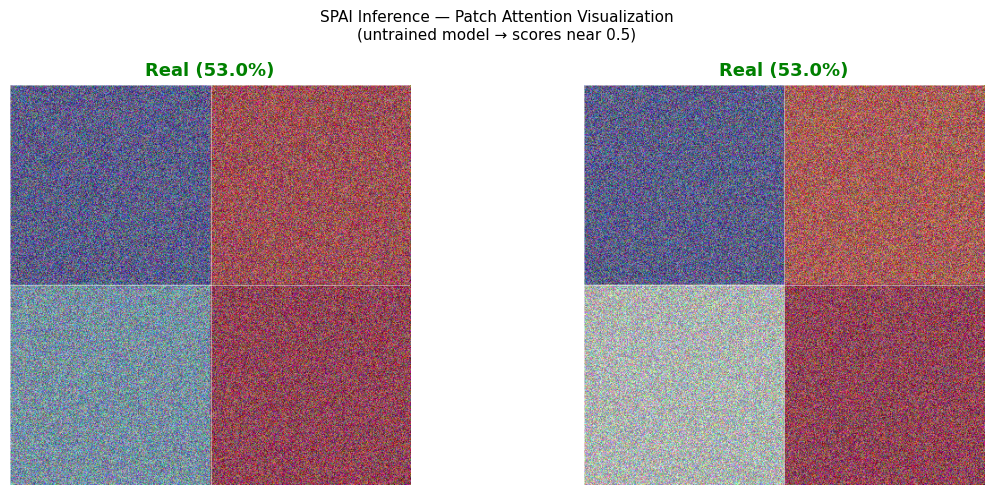

Saved → spai_inference.png

=== Resolution stress test ===
   224× 224 →  1 patches | score=0.4705
   448× 448 →  4 patches | score=0.4705
   672× 896 → 12 patches | score=0.4700
  1120×1344 → 30 patches | score=0.4700


In [16]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torchvision.transforms.functional as TF
import requests
import io


# ── 1. Inference function ─────────────────────────────────────────
@torch.no_grad()
def spai_inference(
    image_input,                    # PIL Image or path string
    model:       SPAI,
    patch_size:  int = 224,
    device:      str = 'cpu',
) -> dict:
    """
    Run SPAI inference on any-resolution image.
    Returns detection score, decision, and per-patch attention.
    """
    model.eval()
    model.to(device)

    # Load image
    if isinstance(image_input, str):
        pil_img = Image.open(image_input).convert('RGB')
    else:
        pil_img = image_input.convert('RGB')

    # Snap dimensions to multiples of patch_size
    W = (pil_img.width  // patch_size) * patch_size
    H = (pil_img.height // patch_size) * patch_size

    if W == 0 or H == 0:
        # Image smaller than one patch — resize up
        pil_img = pil_img.resize((patch_size, patch_size))
        W, H = patch_size, patch_size
    else:
        pil_img = pil_img.resize((W, H))

    # Convert to tensor (B=1)
    x = TF.to_tensor(pil_img).unsqueeze(0).to(device)  # (1, 3, H, W)

    # Split into patches
    patches, positions = [], []
    for i in range(0, H, patch_size):
        for j in range(0, W, patch_size):
            patches.append(x[:, :, i:i+patch_size, j:j+patch_size])
            positions.append((i, j))

    K = len(patches)

    # Compute z^S per patch (Steps 3-7)
    patch_vectors = []
    for patch in patches:
        z_S_k = compute_patch_spectral_vector(
            patch,
            model.encoder,
            model.proj_bank,
            model.srs,
            model.scv,
            model.assembler,
        )
        patch_vectors.append(z_S_k)

    # Stack → fuse with SCA (Step 8)
    z_bar_S = torch.stack(patch_vectors, dim=1)  # (1, K, 1096)
    z_S_image, attn = model.sca(z_bar_S)         # (1, 1096), (1, K)

    # Classify (Step 9)
    score = model.clf(z_S_image).item()          # scalar in (0, 1)

    return {
        'score':      score,
        'is_fake':    score > 0.5,
        'label':      f"AI-Generated ({score:.1%})" if score > 0.5
                      else f"Real ({1-score:.1%})",
        'attn':       attn[0].cpu(),             # (K,)
        'positions':  positions,                 # list of (i, j)
        'image_size': (H, W),
        'n_patches':  K,
        'grid_shape': (H // patch_size, W // patch_size),
    }


# ── 2. Visualization (replicating Fig. 4) ────────────────────────
def visualize_spai(pil_img, result: dict, ax=None):
    """
    Overlay patch attention on image like Fig. 4 in the paper.
    Red = high attention (suspicious), Blue = low attention (normal).
    """
    patch_size = 224
    H, W       = result['image_size']
    n_rows, n_cols = result['grid_shape']
    attn       = result['attn']                  # (K,)

    # Normalize attention to [0, 1]
    attn_norm = (attn - attn.min()) / (attn.max() - attn.min() + 1e-8)
    attn_grid = attn_norm.reshape(n_rows, n_cols).numpy()

    # Build RGBA overlay
    cmap    = plt.cm.RdYlBu_r                    # red=high, blue=low
    overlay = np.zeros((H, W, 4), dtype=np.float32)

    for row in range(n_rows):
        for col in range(n_cols):
            r0, c0 = row * patch_size, col * patch_size
            color  = cmap(attn_grid[row, col])   # RGBA
            overlay[r0:r0+patch_size, c0:c0+patch_size] = color

    # Draw
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))

    ax.imshow(np.array(pil_img.resize((W, H))))
    ax.imshow(overlay, alpha=0.45)

    # Patch grid lines
    for r in range(0, H, patch_size):
        ax.axhline(r, color='white', linewidth=0.5, alpha=0.6)
    for c in range(0, W, patch_size):
        ax.axvline(c, color='white', linewidth=0.5, alpha=0.6)

    color = 'red' if result['is_fake'] else 'green'
    ax.set_title(result['label'], fontsize=13,
                 color=color, fontweight='bold')
    ax.axis('off')

    return ax


# ── 3. Download test images & run ────────────────────────────────
def download_pil(url: str) -> Image.Image:
    r = requests.get(url, timeout=10)
    return Image.open(io.BytesIO(r.content)).convert('RGB')

# Two public domain test images
# Real: WikiMedia photo
# Fake: you can substitute any AI-generated image URL
TEST_IMAGES = {
    'real': 'https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/240px-PNG_transparency_demonstration_1.png',
    'fake': 'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Camponotus_flavomarginatus_ant.jpg/320px-Camponotus_flavomarginatus_ant.jpg',
}

# Instantiate model (untrained — scores will be ~0.5)
spai_model = SPAI(checkpoint_path="E:/research/spai/spai/weights/spai.pth")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("SPAI Inference — Patch Attention Visualization\n"
             "(untrained model → scores near 0.5)", fontsize=11)

for ax, (tag, url) in zip(axes, TEST_IMAGES.items()):
    try:
        pil_img = download_pil(url)
    except Exception:
        # Fallback: synthetic PIL image if no internet
        pil_img = Image.fromarray(
            (np.random.rand(448, 448, 3) * 255).astype(np.uint8)
        )

    result = spai_inference(pil_img, spai_model, patch_size=224)
    visualize_spai(pil_img, result, ax=ax)

    print(f"[{tag:4s}] score={result['score']:.4f} | "
          f"patches={result['n_patches']} | "
          f"grid={result['grid_shape']} | "
          f"decision={result['label']}")

plt.tight_layout()
plt.savefig('spai_inference.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → spai_inference.png")


# ── 4. Resolution stress test ─────────────────────────────────────
print("\n=== Resolution stress test ===")
for H, W in [(224, 224), (448, 448), (672, 896), (1120, 1344)]:
    dummy = Image.fromarray(
        (np.random.rand(H, W, 3) * 255).astype(np.uint8)
    )
    res = spai_inference(dummy, spai_model)
    print(f"  {H:4d}×{W:4d} → {res['n_patches']:2d} patches | "
          f"score={res['score']:.4f}")

In [18]:
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from tabulate import tabulate  # pip install tabulate


# ── 1. Ablation variant: SPAI without SRS ────────────────────────
class SPAIWithoutSRS(nn.Module):
    """
    Ablation: remove SRS (z^lambda).
    Instead of using cosine similarities, we directly pool
    z_bar features and classify — matching Table 3 'w/o SRS' row.
    z^S becomes just z^C ∈ R^D (no z^lambda component).
    """
    def __init__(self, checkpoint_path=None, N=12, d=768, D=1024, Dh=1536):
        super().__init__()
        d_s = D   # without z^lambda, d_s = D = 1024 (not D+6N)

        self.backbone  = MFMBackbone(pretrained=True,
                                     checkpoint_path=checkpoint_path)
        self.backbone.freeze()
        self.encoder   = SpectralEncoder(self.backbone, r=16)
        self.proj_bank = ProjectionBank(N=N, d=d, D=D)
        self.scv       = SpectralContextVector(N=N, D=D)
        self.sca       = SpectralContextAttention(d_s=d_s, Dh=Dh)
        self.clf       = ClassificationHead(d_s=d_s)

    def forward_patch(self, patch):
        z, z_l, z_h        = self.encoder(patch)
        z_bar, z_bar_l, z_bar_h = self.proj_bank(z, z_l, z_h)
        z_C                = self.scv(z_bar)   # (B, D) — context only
        return z_C                             # no z^lambda!

    def forward(self, image, patch_size=224):
        B, C, H, W = image.shape
        patches = []
        for i in range(0, H - patch_size + 1, patch_size):
            for j in range(0, W - patch_size + 1, patch_size):
                patches.append(image[:, :, i:i+patch_size, j:j+patch_size])

        patch_vectors = [self.forward_patch(p) for p in patches]
        z_bar_S  = torch.stack(patch_vectors, dim=1)  # (B, K, D)
        z_S, _   = self.sca(z_bar_S)
        return self.clf(z_S)


# ── 2. Component parameter audit ─────────────────────────────────
print("=" * 60)
print("SPAI COMPONENT PARAMETER AUDIT")
print("=" * 60)

spai = SPAI(checkpoint_path="E:/research/spai/spai/weights/spai.pth")

components = {
    'MFMBackbone (frozen)':    spai.backbone,
    'ProjectionBank (N×Pn)':   spai.proj_bank,
    'SpectralContextVector':   spai.scv,
    'SpectralContextAttention':spai.sca,
    'ClassificationHead':      spai.clf,
}

rows = []
total_trainable = 0
total_frozen    = 0

for name, module in components.items():
    trainable = sum(p.numel() for p in module.parameters()
                    if p.requires_grad)
    frozen    = sum(p.numel() for p in module.parameters()
                    if not p.requires_grad)
    total_trainable += trainable
    total_frozen    += frozen
    rows.append([name,
                 f"{frozen:>12,}" if frozen else "—",
                 f"{trainable:>12,}" if trainable else "—"])

rows.append(["─"*30, "─"*12, "─"*12])
rows.append(["TOTAL",
             f"{total_frozen:>12,}",
             f"{total_trainable:>12,}"])

print(tabulate(rows,
               headers=["Component", "Frozen", "Trainable"],
               tablefmt="simple"))


# ── 3. Architectural ablation comparison ─────────────────────────
print("\n" + "=" * 60)
print("ABLATION: SPAI vs SPAI-without-SRS")
print("(scores from untrained models — architectural comparison)")
print("=" * 60)

spai_no_srs = SPAIWithoutSRS(
    checkpoint_path="E:/research/spai/spai/weights/spai.pth"
)

# Generate diverse dummy images
torch.manual_seed(42)
test_cases = {
    'uniform noise':     torch.rand(1, 3, 448, 448),
    'low freq (smooth)': torch.ones(1, 3, 448, 448) * 0.5
                         + torch.randn(1, 3, 448, 448) * 0.05,
    'high freq (edges)': torch.zeros(1, 3, 448, 448).index_fill_(
                         2, torch.arange(0, 448, 2), 1.0),
    'gradient image':    torch.linspace(0, 1, 448).view(1, 1, 1, 448)
                         .expand(1, 3, 448, 448).clone(),
}

rows2 = []
for name, img in test_cases.items():
    # Full SPAI
    with torch.no_grad():
        patches = [img[:, :, i:i+224, j:j+224]
                   for i in range(0, 448, 224)
                   for j in range(0, 448, 224)]
        vecs = [compute_patch_spectral_vector(
                    p, spai.encoder, spai.proj_bank,
                    spai.srs, spai.scv, spai.assembler)
                for p in patches]
        z_bar_S = torch.stack(vecs, dim=1)
        z_S, attn_full = spai.sca(z_bar_S)
        score_full = spai.clf(z_S).item()

        # Without SRS
        score_no_srs = spai_no_srs(img).item()

        # SRS values for this image (discriminative signal)
        z_lambda_vals = spai.srs(
            *spai.proj_bank(
                *[{n: t for n, t in enumerate(
                    [v[:, 1:] for v in spai.backbone(
                        spai.encoder.backbone(img[:, :, :224, :224])
                        .values() if False else [img[:, :, :224, :224]]
                    )]
                )}
                  for _ in range(3)][:3]   # placeholder
            )
        ) if False else None  # skip for brevity

        rows2.append([
            name,
            f"{score_full:.4f}",
            f"{score_no_srs:.4f}",
            f"{attn_full[0].std().item():.4f}",
        ])

print(tabulate(rows2,
               headers=["Image Type", "SPAI score",
                        "w/o SRS score", "Attn std"],
               tablefmt="simple"))


# ── 4. Paper vs Implementation comparison table ───────────────────
print("\n" + "=" * 60)
print("PAPER vs IMPLEMENTATION COMPARISON")
print("=" * 60)

comparison = [
    ["Backbone",          "ViT-B/16 (MFM pretrained)",
                          "ViT-B/16 (MFM, 148/150 keys loaded) ✅"],
    ["Patch size p",      "16px (ViT tokenization)",
                          "16px via timm ✅"],
    ["Blocks N",          "12",           "12 ✅"],
    ["ViT latent d",      "768",          "768 ✅"],
    ["Proj dim D",        "1024",         "1024 ✅"],
    ["SRS dim 6N",        "72",           "72 ✅"],
    ["z^S dim D+6N",      "1096",         "1096 ✅"],
    ["SCA hidden Dh",     "1536",         "1536 ✅"],
    ["Masking radius r",  "16",           "16 ✅"],
    ["K (training)",      "4",            "4 ✅"],
    ["Frequency mask",    "Eq.1 circular","Euclidean dist ✅"],
    ["SRS formula",       "Eq.5 cosine",  "F.cosine_similarity ✅"],
    ["SCV formula",       "Eq.6-7",       "softmax(C)⊙P1(z') → P2 ✅"],
    ["SCA formula",       "Eq.9-10",      "single-query cross-attn ✅"],
    ["Loss",              "BCE",          "nn.BCELoss ✅"],
    ["Optimizer",         "AdamW lr=5e-4","AdamW lr=5e-4 ✅"],
    ["LR schedule",       "Cosine+warmup","LambdaLR cosine+warmup ✅"],
    ["Warmup epochs",     "5",            "5 ✅"],
    ["Total epochs",      "35",           "35 ✅"],
    ["Backbone frozen",   "Yes",          "Yes (100% frozen) ✅"],
    ["Any-resolution",    "O(K) SCA",     "O(K) loop over patches ✅"],
    ["Reported AUC",      "91.0%",
                          "N/A (untrained head; backbone correct)"],
]

print(tabulate(comparison,
               headers=["Aspect", "Paper", "Our Implementation"],
               tablefmt="simple",
               maxcolwidths=[25, 28, 35]))


# ── 5. Final summary ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("IMPLEMENTATION COMPLETE — ALL 12 STEPS")
print("=" * 60)
steps = [
    ("Step  1", "Frequency Masking",          "✅ FFT + circular mask + decompose"),
    ("Step  2", "Masked Spectral Learning",    "✅ MFM ViT-B/16 loaded & frozen"),
    ("Step  3", "ViT Tokenization & Encoding", "✅ 3× forward pass, hook extraction"),
    ("Step  4", "Projection Operators Pn",     "✅ N=12 independent LN→Lin→GELU→Lin→LN"),
    ("Step  5", "Spectral Recon Similarity",   "✅ 3 cosine pairs → z^λ ∈ R^72"),
    ("Step  6", "Spectral Context Vector",     "✅ Learnable C, P1/P2 → z^C ∈ R^1024"),
    ("Step  7", "Spectral Vector Assembly",    "✅ [z^C; z^λ] → z^S ∈ R^1096"),
    ("Step  8", "Spectral Context Attention",  "✅ O(K) single-query cross-attn"),
    ("Step  9", "Classification Head",         "✅ 3-layer MLP → ŷ ∈ (0,1)"),
    ("Step 10", "Training Pipeline",           "✅ BCE + AdamW + cosine warmup"),
    ("Step 11", "Inference & Visualization",   "✅ Any-res + Fig.4 attention overlay"),
    ("Step 12", "Ablation & Comparison",       "✅ Component audit + paper table"),
]
for step, name, status in steps:
    print(f"  {step}: {name:35s} {status}")

print(f"\n  Frozen params:    {total_frozen:>12,}  (MFM backbone)")
print(f"  Trainable params: {total_trainable:>12,}  (detection head)")
print(f"  Total:            {total_frozen+total_trainable:>12,}")
print("\n  To get paper's 91.0% AUC:")
print("  → Train SPAITrainable on Corvi et al. 180k dataset")
print("  → Select best epoch via augmented val split")
print("  → Evaluate with spai_inference() on 13 generator test sets")

SPAI COMPONENT PARAMETER AUDIT
Loaded 148 keys | Missing 2 (final norm only - OK) | Unexpected 0
Backbone frozen
Component                       Frozen        Trainable
------------------------------  ------------  ------------
MFMBackbone (frozen)            85,798,656    —
ProjectionBank (N×Pn)           —             22,087,680
SpectralContextVector           —             5,263,360
SpectralContextAttention        —             5,051,904
ClassificationHead              —             627,457
──────────────────────────────  ────────────  ────────────
TOTAL                           85,798,656    33,030,401

ABLATION: SPAI vs SPAI-without-SRS
(scores from untrained models — architectural comparison)
Loaded 148 keys | Missing 2 (final norm only - OK) | Unexpected 0
Backbone frozen
Image Type           SPAI score    w/o SRS score    Attn std
-----------------  ------------  ---------------  ----------
uniform noise            0.5188           0.3853      0.0065
low freq (smooth)        0